In [1]:
import pandas as pd
import numpy as np
import pyarrow
import matplotlib.pyplot as plt
from ml_utils.src import *
from ml_utils.config import *
import itertools
import gc 

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import  train_test_split
from sklearn.metrics import classification_report

import keras
from keras.models import Sequential
from keras.layers import Dense, Input, Dropout
from keras import optimizers

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from keras.regularizers import l2


print(tf.config.list_physical_devices())
BATCH_SIZE = 64

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# 1.0 - Classificação de Presença Baseada em Fatores Socioeconômicos Usando Redes Neurais

In [2]:
colunas = ['Q001','Q002','Q003', 'Q004', 'Q005', 'Q006', 'Q007', 'Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 
           'Q019', 'Q020', 'Q021', 'Q022', 'Q023', 'Q024', 'Q025', 'TP_PRESENCA_LC', 'TP_PRESENCA_CH', 'TP_PRESENCA_CN', 'TP_PRESENCA_MT', 
           'TP_FAIXA_ETARIA', 'TP_SEXO','TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_ESCOLA', 'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 
           'NU_ANO', 'TP_LOCALIZACAO_ESC','TP_SIT_FUNC_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_DEPENDENCIA_ADM_ESC']

df_treino = pd.read_parquet(DATA_DIR, columns = colunas)
df_teste = pd.read_parquet("2023", columns = colunas)

## 1.2- Pré-Processando os Dados

In [3]:
df_treino = preparar_dados(df_treino, objetivo = 'Desempenho', n_samples = 400_000)
df_teste = preparar_dados(df_teste, objetivo = 'Desempenho', n_samples = 100_000)

## 1.3- Construção da Matriz X e Vetor y

In [12]:
X_treino = df_treino.drop(columns=['MEDIA', 'FALTOU'])
y_treino = df_treino['MEDIA']

X_teste = df_teste.drop(columns=['MEDIA', 'FALTOU'])
y_teste = df_teste['MEDIA']

## 1.4 - Separação em Dados de Treino, Validação e Teste

In [13]:
X_train, X_val, y_train, y_val = train_test_split(X_treino, y_treino, test_size=0.2, random_state=42)

quantil = y_train.quantile(0.5)

y_train = (y_train >= quantil).astype(int)
y_val   = (y_val   >= quantil).astype(int)

## 1.5 - Tratando os Dados

In [14]:
preprocessador = pre_processor(X_train)

X_train = preprocessador.transform(X_train).astype(np.float32)
X_val   = preprocessador.transform(X_val).astype(np.float32)

In [15]:
max_neurons = num_max_neuronio(X_train, d = X_train.shape[1])
print("Número máximo de neurônios:", max_neurons)

Número máximo de neurônios: 139


## 1.6 - Estourando a rede

In [14]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(256, kernel_initializer='he_normal', 
                activation='relu'))

model.add(Dense(256, kernel_initializer='he_normal', 
                activation='relu'))

model.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,081 (305.00 KB)

 Trainable params: 78,081 (305.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
history = model.fit(X_train, y_train, epochs=100, batch_size = BATCH_SIZE, validation_data=(X_val, y_val), verbose=1)

Epoch 1/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6975 - loss: 0.5760 - val_accuracy: 0.7155 - val_loss: 0.5611
Epoch 2/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7076 - loss: 0.5614 - val_accuracy: 0.7108 - val_loss: 0.5595
Epoch 3/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7090 - loss: 0.5573 - val_accuracy: 0.7109 - val_loss: 0.5560
Epoch 4/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7108 - loss: 0.5554 - val_accuracy: 0.7132 - val_loss: 0.5563
Epoch 5/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7115 - loss: 0.5537 - val_accuracy: 0.7096 - val_loss: 0.5603
Epoch 6/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7121 - loss: 0.5520 - val_accuracy: 0.7135 - val_loss: 0.5554
Epoch 7/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7145 - loss: 0.5502 - val_accuracy: 0.7098 - val_loss: 0.5579
Epoch 8/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7153 - loss: 0

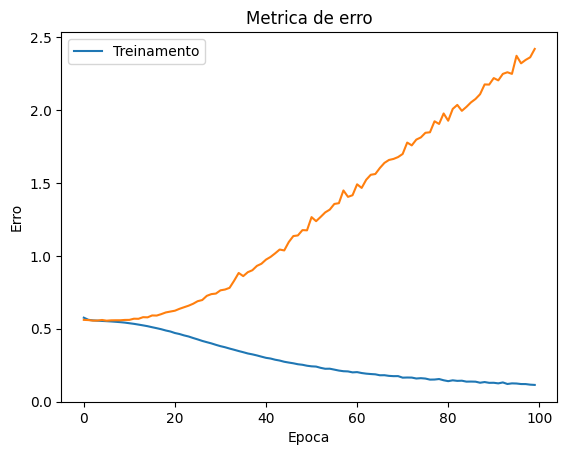


--> Acuracia (treino): 0.9612
--> Acuracia (teste): 0.6473
--> E_val - E_in = 2.3190
--> acc_train - acc_val = 0.3139


In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

E_val, acc_val = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_val:.4f}')
print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

In [29]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2(0.001),
                activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2(0.001),
                activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

Model: "sequential_92"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_184 (Dense)               │ (None, 256)            │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_185 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_186 (Dense)               │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,081 (305.00 KB)

 Trainable params: 78,081 (305.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [30]:
history = model.fit(X_train, y_train, epochs=100, batch_size = BATCH_SIZE,
                    validation_data=(X_val, y_val),
                    verbose=1)

Epoch 1/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6689 - loss: 1.0685 - val_accuracy: 0.7042 - val_loss: 0.7767
Epoch 2/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6982 - loss: 0.7003 - val_accuracy: 0.6993 - val_loss: 0.6457
Epoch 3/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7000 - loss: 0.6214 - val_accuracy: 0.7089 - val_loss: 0.5958
Epoch 4/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7027 - loss: 0.5958 - val_accuracy: 0.7084 - val_loss: 0.5810
Epoch 5/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7037 - loss: 0.5861 - val_accuracy: 0.7090 - val_loss: 0.5777
Epoch 6/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7022 - loss: 0.5815 - val_accuracy: 0.7094 - val_loss: 0.5724
Epoch 7/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7038 - loss: 0.5794 - val_accuracy: 0.7104 - val_loss: 0.5713
Epoch 8/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7036 - loss: 0

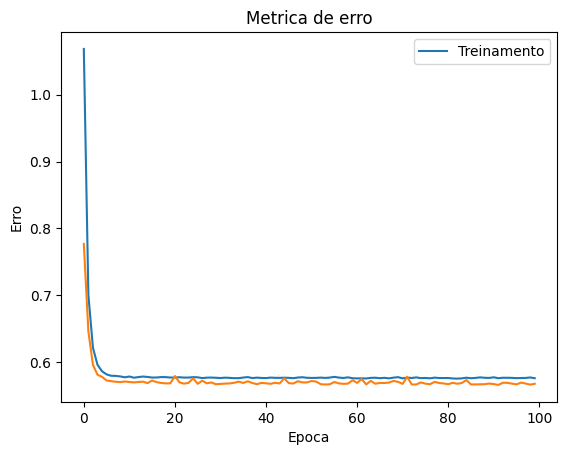


--> Acuracia (treino): 0.7082
--> Acuracia (teste): 0.7108
--> E_val - E_in = 0.0014
--> acc_train - acc_val = -0.0026


In [31]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Metrica de erro')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(['Treinamento'])
plt.show()

E_in, acc_train = model.evaluate(X_train, y_train, batch_size=BATCH_SIZE, verbose=0)

E_val, acc_val = model.evaluate(X_val, y_val, batch_size=BATCH_SIZE, verbose=0)

print(f'\n--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_val:.4f}')
print(f"--> E_val - E_in = {E_val - E_in:.4f}")
print(f"--> acc_train - acc_val = {acc_train - acc_val:.4f}")

## 1.7 - Treinando a Rede Neural com melhores parâmetros

In [16]:
preprocessador = pre_processor(X_treino)

X_treino = preprocessador.transform(X_treino).astype(np.float32)
X_teste  = preprocessador.transform(X_teste).astype(np.float32)

quantil = y_treino.quantile(0.5)

y_treino = (y_treino >= quantil).astype(int)
y_teste   = (y_teste   >= quantil).astype(int)

In [17]:
param_grid = {
    'neurons':       [max_neurons - 1],
    'learning_rate': [0.01, 0.001, 0.0001],   
    'batch_size':    [64],             
    'epochs':        [100],
    'l2_reg':        [0.001, 0.01, 0.1],          
    'dropout':       [0.0, 0.2],
}

keys, values = zip(*param_grid.items())
combinacoes = [dict(zip(keys, v)) for v in itertools.product(*values)]
print(f"Total de combinações: {len(combinacoes)}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = []

for params in combinacoes:
    print(f"Testando: {params}")
    
    accs = []

    for train_idx, val_idx in skf.split(X_treino, y_treino):
        X_tr, X_val_fold = X_treino[train_idx], X_treino[val_idx]
        y_tr, y_val_fold = y_treino.iloc[train_idx], y_treino.iloc[val_idx]

        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        classes = np.unique(y_tr)
        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_tr
        )

        class_weight = dict(zip(classes, weights))
        model = create_model(
            input_dim=X_treino.shape[1],
            neurons=params['neurons'],
            learning_rate=params['learning_rate'],
            l2_reg=params['l2_reg'],
            dropout=params['dropout']
        )

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val_fold, y_val_fold),
            epochs=params['epochs'],
            batch_size=params['batch_size'],
            callbacks=[early_stop],
            class_weight=class_weight,
            verbose=1
        )

        loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        accs.append(acc)

        del model
        gc.collect()

    mean_acc = np.mean(accs)

    resultados.append({
        'params': params,
        'mean_accuracy': mean_acc
    })

    print(f"Accuracy média: {mean_acc:.4f}")

Total de combinações: 18
Testando: {'neurons': 138, 'learning_rate': 0.01, 'batch_size': 64, 'epochs': 100, 'l2_reg': 0.001, 'dropout': 0.0}
Epoch 1/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6976 - loss: 0.6039 - val_accuracy: 0.7048 - val_loss: 0.5779
Epoch 2/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7004 - loss: 0.5781 - val_accuracy: 0.7089 - val_loss: 0.5691
Epoch 3/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7026 - loss: 0.5732 - val_accuracy: 0.7027 - val_loss: 0.5778
Epoch 4/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7025 - loss: 0.5713 - val_accuracy: 0.7083 - val_loss: 0.5692
Epoch 5/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7033 - loss: 0.5712 - val_accuracy: 0.7099 - val_loss: 0.5710
Epoch 6/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7023 - loss: 0.5707 - val_accuracy: 0.7090 - val_loss: 0.5653
Epoch 7/100
1045/1045 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7026

In [18]:
resultados_df = pd.DataFrame(resultados)
resultados_df = resultados_df.sort_values(by='mean_accuracy', ascending=False)

In [19]:
resultados_df.to_csv("resultados_desempenho_socioeconomicos.csv", index=False)

In [20]:
resultados_df = pd.read_csv("resultados_desempenho_socioeconomicos.csv")

In [21]:
resultados_df.params[0]

"{'neurons': 138, 'learning_rate': 0.0001, 'batch_size': 64, 'epochs': 100, 'l2_reg': 0.001, 'dropout': 0.2}"

## Treinando o modelo com todos os dados e testando no ano de 2023

In [26]:
adam = Adam(learning_rate=0.0001)

model = Sequential()

model.add(Input(shape=(X_treino.shape[1],)))

model.add(Dense(138, kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.001), 
                activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(1, kernel_initializer='he_normal', activation='sigmoid'))

# Compilar o modelo
model.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

print(model.summary())

Model: "sequential_91"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_182 (Dense)               │ (None, 138)            │         6,486 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 138)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_183 (Dense)               │ (None, 1)              │           139 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,625 (25.88 KB)

 Trainable params: 6,625 (25.88 KB)

 Non-trainable params: 0 (0.00 B)

None


In [27]:
history = model.fit(X_treino, y_treino,
                    epochs=100,
                    batch_size=BATCH_SIZE) 

# Obtendo a acuracia no conjunto de treinamento
E_in, acc_train = model.evaluate(X_treino, y_treino, batch_size=BATCH_SIZE, verbose=0)

# Obtendo a acuracia no conjunto de teste
E_test, acc_test = model.evaluate(X_teste, y_teste, batch_size=BATCH_SIZE, verbose=0)

print(f"--> E_test - E_in = {E_test - E_in:.4f}")
print(f'--> Acuracia (treino): {acc_train:.4f}')
print(f'--> Acuracia (teste): {acc_test:.4f}')
print(f"--> acc_train - acc_test = {acc_train - acc_test:.4f}")

Epoch 1/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 2s 921us/step - accuracy: 0.6371 - loss: 0.9107
Epoch 2/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 1s 925us/step - accuracy: 0.6782 - loss: 0.7571
Epoch 3/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6907 - loss: 0.6965
Epoch 4/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6976 - loss: 0.6656
Epoch 5/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 1s 947us/step - accuracy: 0.7032 - loss: 0.6442
Epoch 6/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 1s 928us/step - accuracy: 0.7020 - loss: 0.6322
Epoch 7/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 1s 941us/step - accuracy: 0.7047 - loss: 0.6220
Epoch 8/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - accuracy: 0.7052 - loss: 0.6140
Epoch 9/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7073 - loss: 0.6070
Epoch 10/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - accuracy: 0.7066 - loss: 0.6017
Epoch 11/100
1306/1306 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - accuracy: 0.7077 - loss: 0.5972
Epo

In [28]:
y_pred_proba = model.predict(X_teste)
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_teste, y_pred))

803/803 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step
              precision    recall  f1-score   support

           0       0.62      0.78      0.69     11325
           1       0.78      0.62      0.69     14347

    accuracy                           0.69     25672
   macro avg       0.70      0.70      0.69     25672
weighted avg       0.71      0.69      0.69     25672

